In [1]:


import os
import scipy.io
import h5py
import numpy as np
import sys
from scipy import signal as sig
from scipy import stats as stats
import math
import pandas as pd
import csv
import matplotlib.pyplot as plt
from scipy import signal
import seaborn as sns
import logging

%matplotlib widget

scripts_path = '/home/apollo/Documents/github_projects/ripple_sync/scripts/hc_11_scripts/'
os.chdir(scripts_path)


import hc11_BaseFunctions as hc11_bf

scripts_path = '/home/apollo/Documents/github_projects/ripple_sync/scripts/hc_18_scripts/'
data_path = "/media/apollo/projects/hc-18/data/"
os.chdir(scripts_path)

import hc18_BaseFunctions as hc18_bf
import smoothing_functions as smooth
import normalizing_functions as norm
import smoothing_functions as smooth

sessions = ['Train-242-20140124','Train-261-20140617','Train-272-20141215','Train-292-20150501','Train-314-20160118']
animals = ['242','261','272','292','314']


In [2]:

def get_speed(x_coords, y_coords, time_vector, speed_smoothing_sigma=1):
    """
    Calculate instantaneous speed from position coordinates and time vector,
    handling both 1D and 2D positions. Applies Gaussian smoothing.

    Parameters:
    - x_coords (array-like): X-coordinate positions (or 1D positions if y_coords is None).
    - time_vector (array-like): Time stamps corresponding to the positions.
    - y_coords (array-like or None): Y-coordinate positions. If None, assumes 1D data.
    - speed_smoothing_sigma (float): Std deviation for Gaussian smoothing. Default is 1.

    Returns:
    - speed (np.ndarray): Instantaneous speed (not smoothed).
    - smoothed_speed (np.ndarray): Smoothed speed.
    """
    x_coords = np.asarray(x_coords)
    time_vector = np.asarray(time_vector)

    if y_coords is None:
        distances = np.abs(np.diff(x_coords))
    else:
        y_coords = np.asarray(y_coords)
        delta_x = np.diff(x_coords)
        delta_y = np.diff(y_coords)
        distances = np.sqrt(delta_x**2 + delta_y**2)

    time_intervals = np.diff(time_vector)
    if np.any(time_intervals <= 0):
        raise ValueError("Time vector must be strictly increasing.")

    speed = distances / time_intervals
    speed = np.append(speed, 0)  # Pad to match original array length

    sigma_points = smooth.get_sigma_points(speed_smoothing_sigma, time_vector)
    kernel, _ = smooth.generate_1d_gaussian_kernel(sigma_points, radius=None, truncate=4.0)
    smoothed_speed = smooth.gaussian_smooth_1d(speed, kernel, handle_nans=False)

    return speed,smoothed_speed


In [4]:

sessions = ['Train-242-20140124','Train-261-20140617','Train-272-20141215','Train-292-20150501','Train-314-20160118']
animals = ['242','261','272','292','314']

# sessions = ['Train-242-20140124']
# animals = ['261']

In [147]:

event_name = 'SleepBaseline'
event_name = 'SleepPassiveForward'


# for session in sessions[0:1]:
session = sessions[1]
 
print(session)
lfp,srate = hc18_bf.load_lfp_hc18_data(session)
time_vector = np.linspace(0,lfp.shape[1]/srate,lfp.shape[1])

event_times, event_descriptions = hc18_bf.get_events(session, event_name)
event_times = np.array(event_times)
event_times = event_times.reshape(-1,2)
sleep_epoch = []
for event_start,event_end in event_times:
    print(event_start)
    print(event_end)
    print()
    sleep_epoch.append(np.where((time_vector >= event_start) & (time_vector <= event_end))[0])
sleep_epoch = np.unique(np.concatenate(sleep_epoch))


Train-261-20140617
5650.466791950001
8387.54902414

8387.54902414
11470.15802339

16092.05039201
19964.362956459998



In [146]:

# event_name = 'SleepBaseline'
# event_name = 'SleepPassiveForward'

# for session in sessions:
#     print(session)
# # lfp,srate = hc18_bf.load_lfp_hc18_data(session)

#     event_times, event_descriptions = hc18_bf.get_events(session, event_name)
#     print(event_descriptions)
    
#     if event_name == 'SleepPassiveForward' and session == 'Train-292-20150501':
#         event_start = event_times[0]
#         event_end = event_times[3]

#     elif event_name == 'SleepPassiveForward':
#         event_start = event_times[0]
#         event_end = event_times[1]

#     else:
#         event_start = np.nanmin(event_times)
#         event_end = np.nanmax(event_times)
        
#     print(event_start)
#     print(event_end)
#     print()
    

In [148]:

# event_name = 'SleepBaseline'
# event_name = 'SleepPassiveForward'

# session = sessions[0]
# lfp,srate = hc18_bf.load_lfp_hc18_data(session)

# event_times, event_descriptions = hc18_bf.get_events(session, event_name)
# print(event_descriptions)
# print(event_times)
# if event_name == 'SleepPassiveForward' and session == 'Train-242-20140124':
#     event_start = event_times[-4]
#     event_end = event_times[-1]

# elif event_name == 'SleepPassiveForward':
#     event_start = event_times[-2]
#     event_end = event_times[-1]

# else:
#     event_start = np.nanmin(event_times)
#     event_end = np.nanmax(event_times)
    
# print(event_start)
# print(event_end)
# print()

In [150]:

# time_vector = np.linspace(0,lfp.shape[1]/srate,lfp.shape[1])
# sleep_epoch = (time_vector >= event_start) & (time_vector <= event_end)
lfp = lfp[:,sleep_epoch]
time_vector = time_vector[sleep_epoch]


In [69]:
# event_start = 0
# event_end = 100

# lfp_index = np.round(np.arange(event_start*srate,event_end*srate)).astype(int)
# lfp = np.double(lfp[:,lfp_index])
# lfp = sig.detrend(hc11_bf.eegfilt(lfp,srate,1,300))


In [ ]:

# lfp_index = np.round(np.arange(event_start*srate,event_end*srate)).astype(int)
# lfp = np.double(lfp[:,lfp_index])
# lfp = sig.detrend(hc11_bf.eegfilt(lfp,srate,1,300))


In [151]:

theta_filtered = sig.detrend(hc11_bf.eegfilt(lfp[:,0:int(5*60*srate)],srate,5,12))
theta_hilbert = hc11_bf.hilbert(theta_filtered)
theta_amp = np.abs(theta_hilbert)

np.sort(np.nanmean(theta_amp,1))


array([ 963.05078739,  963.57930231,  963.8202286 ,  966.83481317,
       1102.98896931, 1105.74446936, 1106.12692769, 1107.31386507,
       1161.33397067, 1166.69444777, 1167.7848894 , 1201.12387875,
       1255.28046018, 1276.19134627, 1289.93873776, 1304.38421135,
       1512.92592741, 1517.31296938, 1518.02960495, 1519.30558358,
       1669.48264957, 1695.9321474 , 1699.84178037, 1733.5636601 ,
       1742.66384588, 1750.05368903, 1779.36940075, 1804.45700275,
       1832.22693746, 1849.09648546, 1854.57649979, 1868.20479314,
       1872.07177824, 1891.9680194 , 1912.1820579 , 2044.38154026,
       2053.7016672 , 2054.68653724, 2057.65301537, 2058.72629003,
       2060.62550473, 2082.80519159, 2093.65909765, 2102.52557201,
       2120.46286418, 2136.44626504, 2158.1773042 , 2161.20920278,
       2531.86001204, 2596.65831371, 2599.62395773, 2618.28997065,
       2621.74338966, 2624.387799  , 2639.91544195, 2663.61311278,
       2879.81379909, 2896.76002548, 2907.49863819, 2914.45637

In [152]:
np.argsort(np.nanmean(theta_amp,1))



array([ 1,  2,  0,  3, 10, 11,  8,  9,  5,  4,  7,  6, 13, 14, 12, 15, 17,
       18, 19, 16, 22, 61, 60, 63, 23, 62, 27, 26, 25, 31, 28, 29, 30, 20,
       21, 50, 58, 57, 59, 48, 56, 24, 53, 51, 54, 49, 55, 52, 35, 34, 44,
       47, 32, 46, 45, 33, 42, 43, 40, 41, 39, 37, 38, 36])

In [162]:

ch = 11
lfp_norm = sig.detrend(norm.z_score_norm(lfp[ch,:]))

delta_filtered = sig.detrend(hc11_bf.eegfilt(lfp_norm,srate,0,4))
delta_hilbert = hc11_bf.hilbert(delta_filtered)
delta_amp = np.abs(delta_hilbert)

theta_filtered = sig.detrend(hc11_bf.eegfilt(lfp_norm,srate,5,12))
theta_hilbert = hc11_bf.hilbert(theta_filtered)
theta_amp = np.abs(theta_hilbert)



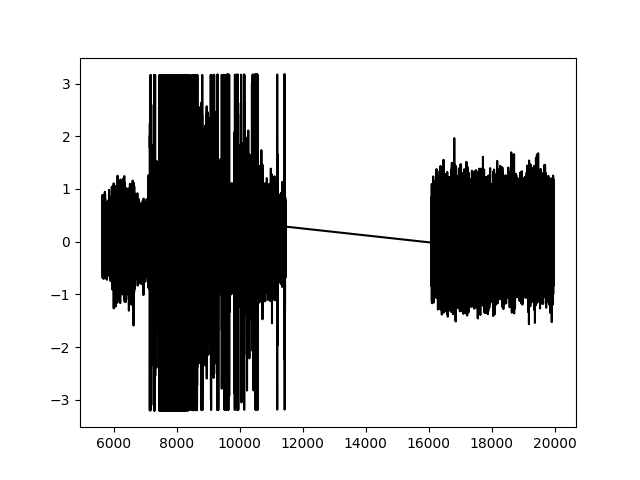

In [163]:

plt.figure()
plt.plot(time_vector,lfp_norm,'k')
plt.show()


In [11]:

# event_name = 'SleepBaseline'
# lfp,srate = hc18_bf.load_lfp_hc18_data(session)

# event_times, event_descriptions = hc18_bf.get_events(session, event_name)
# print(event_times)

# event_times = np.sort(np.array(event_times))

# event_start = event_times[0]
# event_end = event_times[1]

# lfp_norm = lfp[107,:].copy()
# del lfp


In [76]:

# delta_filtered = hc11_bf.eegfilt(lfp_norm,srate,0,4)
# delta_hilbert = hc11_bf.hilbert(delta_filtered)
# delta_amp = np.abs(delta_hilbert)

# theta_filtered = hc11_bf.eegfilt(lfp_norm,srate,5,12)
# theta_hilbert = hc11_bf.hilbert(theta_filtered)
# theta_amp = np.abs(theta_hilbert)


In [164]:

amp_window_length = 5.0*srate
non_overlap = 1.0*srate
overlap = amp_window_length-non_overlap
binned_delta_amplitude = []
binned_theta_amplitude = []
binned_time_vector = []
for ll in np.arange(0,((lfp_norm.shape[0]-amp_window_length)/non_overlap)):
    amp_window = np.arange((amp_window_length-overlap)*ll,(amp_window_length-overlap)*ll + amp_window_length).astype(int)

    binned_delta_amplitude.append(np.nanmean(delta_amp[amp_window]))
    binned_theta_amplitude.append(np.nanmean(theta_amp[amp_window]))
    binned_time_vector.append(np.nanmedian(time_vector[amp_window]))

binned_delta_amplitude = np.array(binned_delta_amplitude)
binned_theta_amplitude = np.array(binned_theta_amplitude)
binned_time_vector = np.array(binned_time_vector)


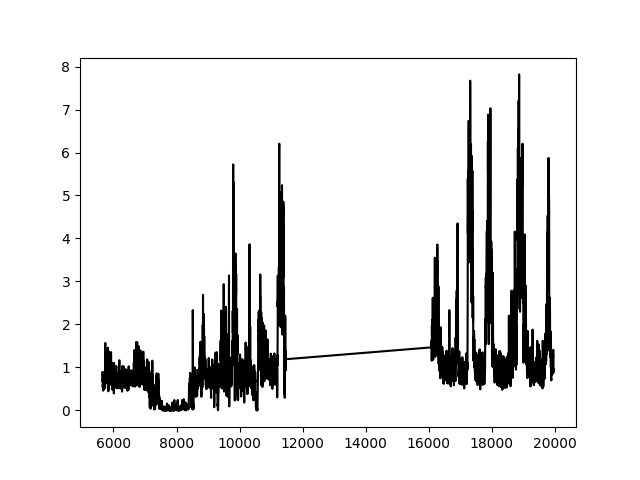

In [165]:

plt.figure()
plt.plot(binned_time_vector,binned_theta_amplitude/binned_delta_amplitude,'k')
plt.show()


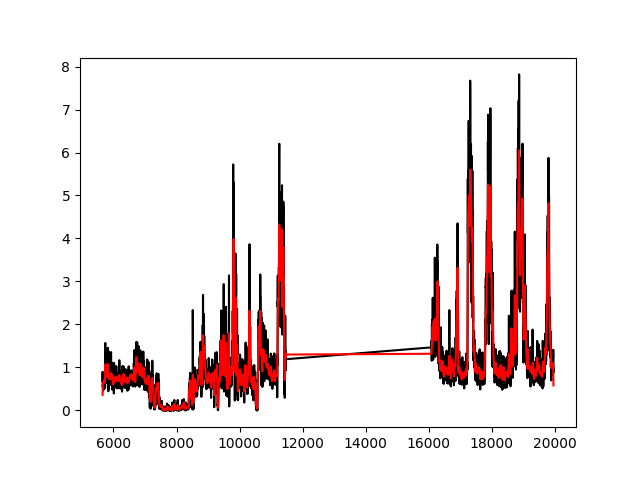

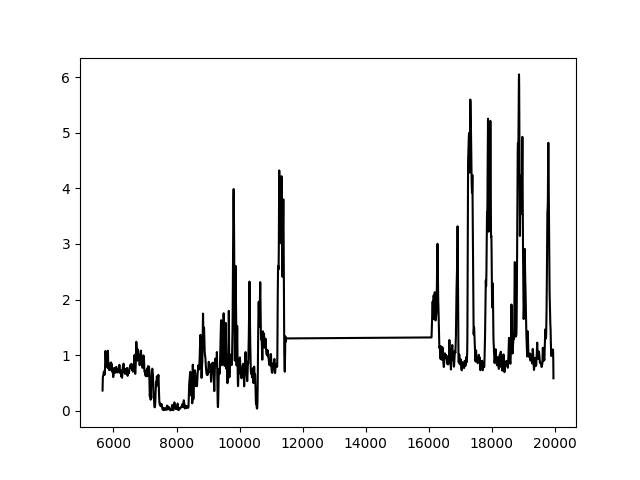

In [166]:
sigma = 10
sigma_points = smooth.get_sigma_points(sigma,binned_time_vector)
kernel, x_values = smooth.generate_1d_gaussian_kernel(sigma_points)

theta_delta_ratio = binned_theta_amplitude/binned_delta_amplitude
theta_delta_ratio_smoothed = smooth.gaussian_smooth_1d(theta_delta_ratio,kernel)

plt.figure()
plt.plot(binned_time_vector,theta_delta_ratio,'k')
plt.plot(binned_time_vector,theta_delta_ratio_smoothed,'r')
plt.show()

theta_delta_ratio_smoothed_norm = norm.robust_z_score_norm(theta_delta_ratio_smoothed)

plt.figure()
plt.plot(binned_time_vector,theta_delta_ratio_smoothed,'k')
plt.show()


In [167]:

threshold = 1.2
theta_index = np.where(theta_delta_ratio_smoothed > threshold)[0]
theta_blocks = hc18_bf.split_into_contiguous_blocks(theta_index)

theta_epochs = []
for theta_block in theta_blocks:
    theta_start = theta_block[0]
    theta_end = theta_block[-1]
    theta_block_idx = np.where((time_vector >= binned_time_vector[theta_start]) & (time_vector <= binned_time_vector[theta_end]))[0]
    theta_epochs.append(theta_block_idx)
theta_epochs = np.unique(np.concatenate(theta_epochs))


In [159]:

delta_index = np.where(theta_delta_ratio_smoothed < threshold)[0]
delta_blocks = hc18_bf.split_into_contiguous_blocks(delta_index)

delta_epochs = []
for delta_block in delta_blocks:
    delta_start = delta_block[0]
    delta_end = delta_block[-1]
    delta_block_idx = np.where((time_vector >= binned_time_vector[delta_start]) & (time_vector <= binned_time_vector[delta_end]))[0]
    delta_epochs.append(delta_block_idx)
delta_epochs = np.unique(np.concatenate(delta_epochs))
# delta_epochs = np.delete(np.arange(time_vector.shape[0]),theta_epochs)


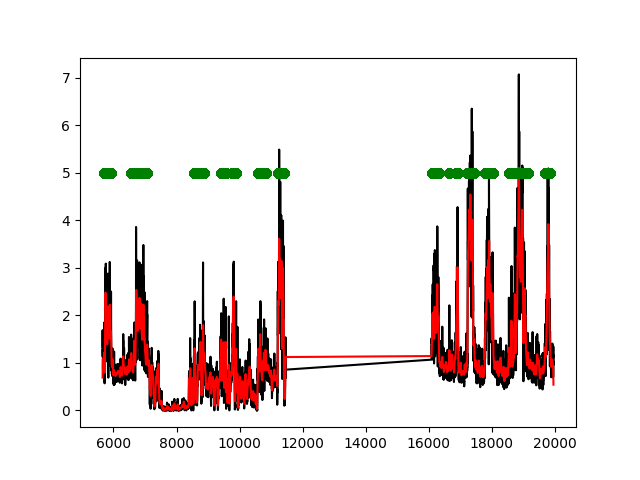

In [160]:

plt.close('all')
plt.figure()
plt.plot(binned_time_vector,theta_delta_ratio,'k')
plt.plot(binned_time_vector,theta_delta_ratio_smoothed,'r')
plt.plot(time_vector[theta_epochs],5*np.ones(theta_epochs.shape[0]),'go')
plt.show()


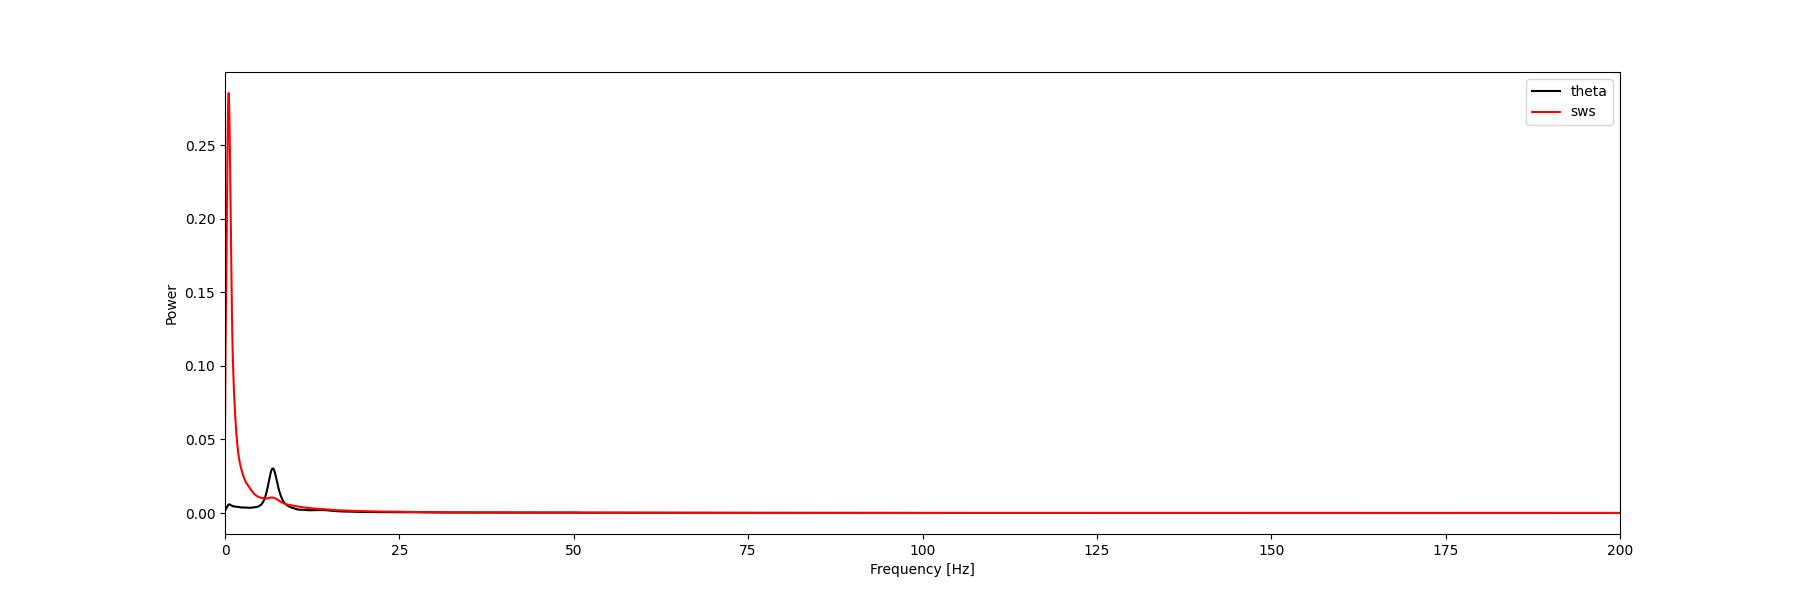

In [161]:

plt.figure(figsize=(18,6))

window = 2*srate
f, pxx = sig.welch(lfp_norm[theta_epochs], fs=srate, window='hann', nperseg=window, noverlap=window/2, nfft=2**14, detrend='constant', return_onesided=True, scaling='density', axis=-1, average='mean')
plt.plot(f, pxx, ls = '-', color = 'k',label='theta')


f, pxx = sig.welch(lfp_norm[delta_epochs], fs=srate, window='hann', nperseg=window, noverlap=window/2, nfft=2**14, detrend='constant', return_onesided=True, scaling='density', axis=-1, average='mean')
plt.plot(f, pxx, ls = '-', color = 'r',label='sws')


plt.legend()
plt.xlim([0,200])
plt.xlabel('Frequency [Hz]')
plt.ylabel('Power')
plt.show()



In [143]:

def save_data(filename, data, description=None):
    with open(filename, 'wb') as f:
        np.save(f, data)
    if description:
        print(f"{description} saved to {filename}.")

file_path = f'{data_path}/{session}/'
filename = f'{session}_{event_name}_sws_epoch'
save_data(file_path + filename, delta_epochs)


In [87]:
sws_epochs = np.load(file_path + filename)
sws_epochs

array([   3125,    3126,    3127, ..., 4836872, 4836873, 4836874],
      shape=(3355000,))

In [20]:

x_coordinates, y_coordinates, track_time_vector, video_srate = hc18_bf.load_pos(session)
x_coordinates = x_coordinates.astype(float)
y_coordinates = y_coordinates.astype(float)

pos_ephc = (track_time_vector >= event_start) & (track_time_vector <= event_end)
x_coordinates[x_coordinates==-1] = np.nan
x_coordinates = x_coordinates[pos_ephc]

y_coordinates[y_coordinates==-1] = np.nan
y_coordinates = y_coordinates[pos_ephc]

track_time_vector = track_time_vector[pos_ephc]


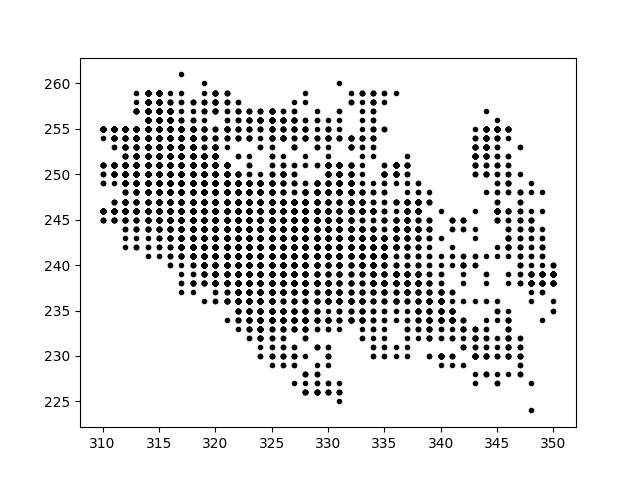

In [21]:

plt.figure()
plt.plot(x_coordinates, y_coordinates,'k.')
plt.show()


In [22]:

speed,smoothed_speed = get_speed(x_coordinates, y_coordinates, track_time_vector,speed_smoothing_sigma=1)


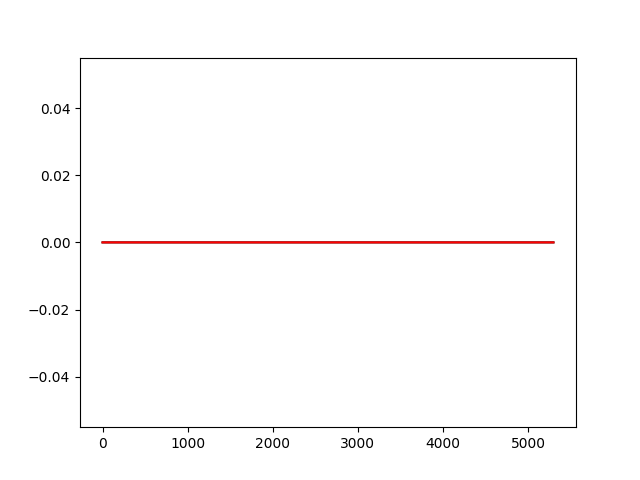

In [86]:

plt.figure()
plt.plot(track_time_vector,speed,'k')
plt.plot(track_time_vector,smoothed_speed,'r')
plt.show()


In [87]:
amp_window_length = 1.0*srate
overlap = 0.5*srate

non_overlap = amp_window_length - overlap
num_windows = int((len(time_vector) - amp_window_length) / non_overlap)

binned_delta_amplitude = []
binned_theta_amplitude = []
binned_speed = []
binned_time_windows = []
binned_time_vector = []
for i in range(num_windows):
    start = int(i * non_overlap)
    end = int(start + amp_window_length)
    amp_window = slice(start, end)
    t_start, t_end = time_vector[start], time_vector[end - 1]
    video_window = (track_time_vector >= t_start) & (track_time_vector <= t_end)

    binned_delta_amplitude.append(np.nanmean(delta_amp[amp_window]))
    binned_theta_amplitude.append(np.nanmean(theta_amp[amp_window]))

    binned_speed.append(np.nanmean(smoothed_speed[video_window]))
    binned_time_windows.append(amp_window)
    binned_time_vector.append(np.nanmean(time_vector[amp_window]))
    
binned_speed = np.array(binned_speed)
binned_time_windows = np.array(binned_time_windows)
binned_time_vector = np.array(binned_time_vector)

binned_delta_amplitude = np.array(binned_delta_amplitude)
binned_theta_amplitude = np.array(binned_theta_amplitude)


/tmp/ipykernel_68258/4234582910.py:22: RuntimeWarning: Mean of empty slice
  binned_speed.append(np.nanmean(smoothed_speed[video_window]))


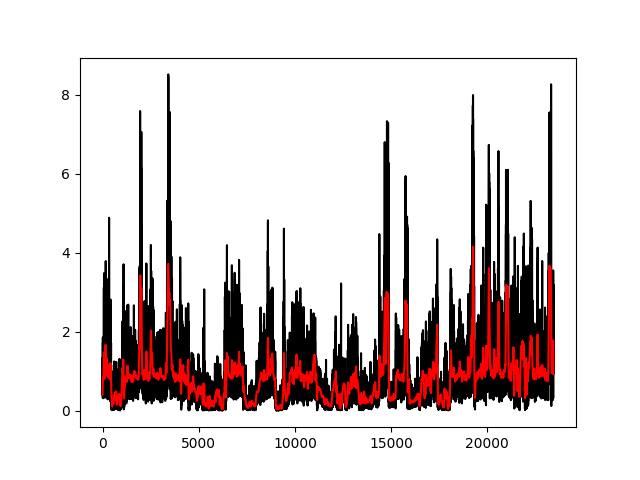

In [92]:

sigma = 10
sigma_points = smooth.get_sigma_points(sigma,binned_time_vector)
kernel, x_values = smooth.generate_1d_gaussian_kernel(sigma_points)

theta_delta_ratio = binned_theta_amplitude/binned_delta_amplitude
theta_delta_ratio_smoothed = smooth.gaussian_smooth_1d(theta_delta_ratio,kernel)


plt.close('all')
plt.figure()
plt.plot(binned_time_vector,theta_delta_ratio,'k')
plt.plot(binned_time_vector,theta_delta_ratio_smoothed,'r')
plt.show()


In [94]:
binned_speed[np.isnan(binned_speed)] = 0
combined_idx = np.r_[tuple(binned_time_windows[(binned_speed<30) & (theta_delta_ratio_smoothed < 1.5)])]
combined_idx = np.sort(combined_idx)


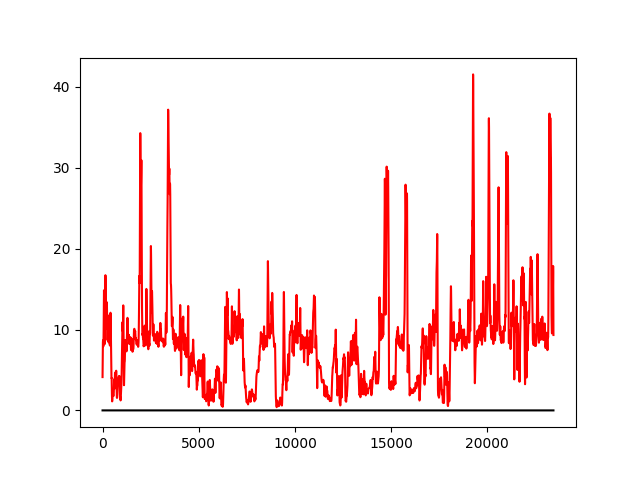

In [90]:

plt.close('all')
plt.figure()
plt.plot(binned_time_vector,binned_speed,'k')
plt.plot(binned_time_vector,10*theta_delta_ratio_smoothed,'r')
plt.show()


In [93]:

plt.figure()
plt.plot(time_vector,lfp_norm,'k')
plt.plot(time_vector[combined_idx],lfp_norm[combined_idx],'r')
plt.plot(binned_time_vector,theta_delta_ratio_smoothed,'g',lw=3)
plt.show()



In [95]:


def save_data(filename, data, description=None):
    with open(filename, 'wb') as f:
        np.save(f, data)
    if description:
        print(f"{description} saved to {filename}.")

file_path = f'{data_path}/{session}/'
filename = f'{session}_{event_name}_sws_epoch'

file_path = f'{data_path}/{session}/'
filename = f'{session}_{event_name}_sws_epoch'
save_data(file_path + filename,combined_idx)


In [9]:
sws_epoch = np.load(filename)
sws_epoch

array([       0,        1,        2, ..., 29301872, 29301873, 29301874],
      shape=(54063750,))

In [11]:
non_sws_epoch = np.delete(np.arange(0,lfp_norm.shape[0]),sws_epoch)
non_sws_epoch

array([  176875,   176876,   176877, ..., 29302622, 29302623, 29302624],
      shape=(2252625,))

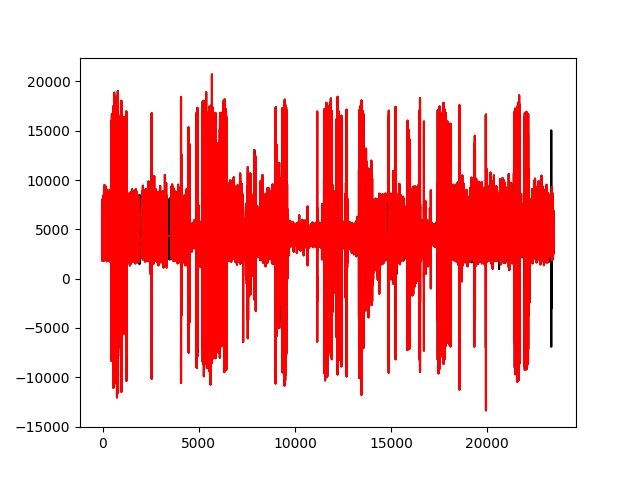

In [99]:

plt.figure()
plt.plot(time_vector,lfp_norm,'k')
plt.plot(time_vector[sws_epoch],lfp_norm[sws_epoch],'r')
plt.show()


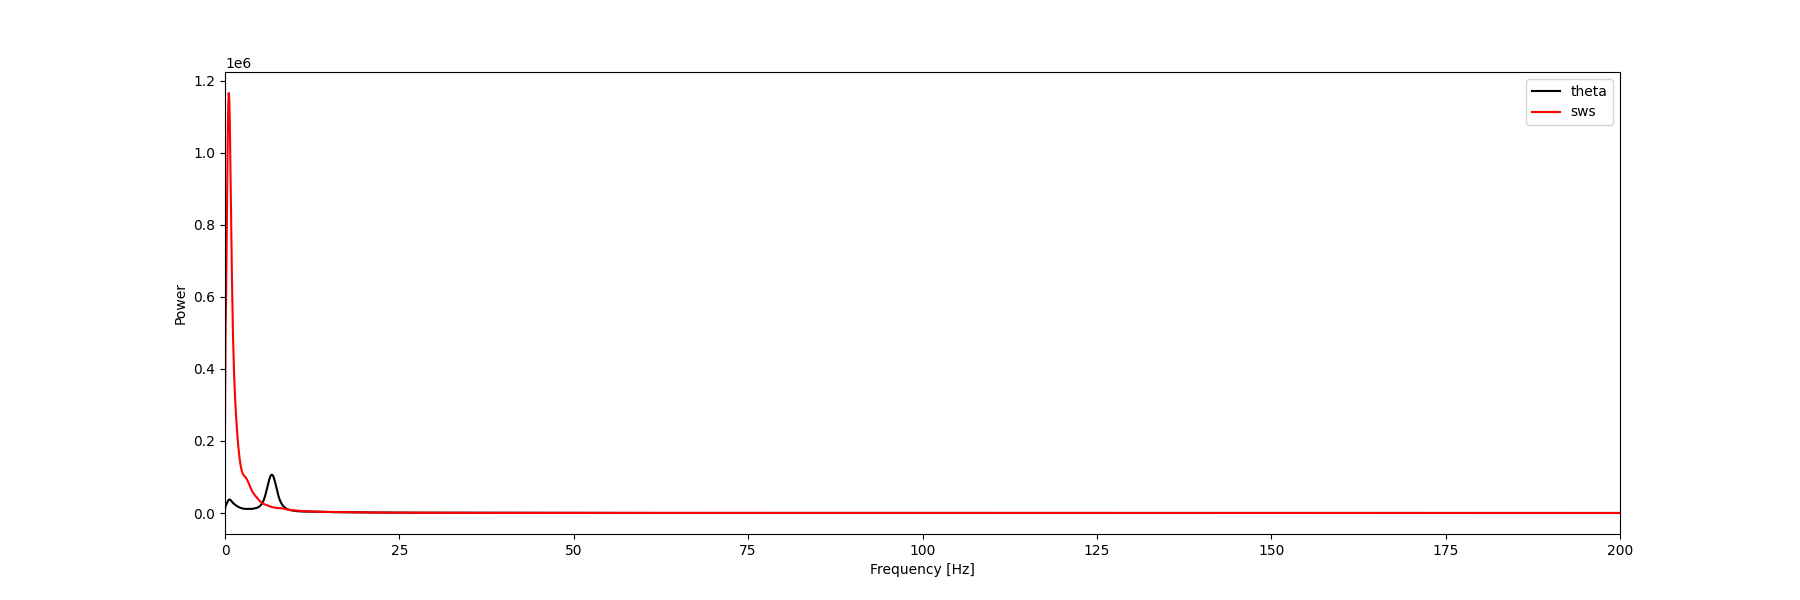

In [12]:
plt.figure(figsize=(18,6))

window = 2*srate
f, pxx = sig.welch(lfp_norm[non_sws_epoch], fs=srate, window='hann', nperseg=window, noverlap=window/2, nfft=2**14, detrend='constant', return_onesided=True, scaling='density', axis=-1, average='mean')
plt.plot(f, pxx, ls = '-', color = 'k',label='theta')


f, pxx = sig.welch(lfp_norm[sws_epoch], fs=srate, window='hann', nperseg=window, noverlap=window/2, nfft=2**14, detrend='constant', return_onesided=True, scaling='density', axis=-1, average='mean')
plt.plot(f, pxx, ls = '-', color = 'r',label='sws')


plt.legend()
plt.xlim([0,200])
plt.xlabel('Frequency [Hz]')
plt.ylabel('Power')
plt.show()



